Import library

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os

Load data

In [ ]:
import tensorflow as tf

In [ ]:
# Mount drive
drive.mount('/content/drive')

# Thêm tham số -o để tự động ghi đè, không bị treo hỏi y/n nữa
!unzip -o -q "/content/drive/MyDrive/TRAYFOODAI2.zip" -d "/content/dataset"

file_path = '/content/dataset/TRAY FOOD AI2/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/dataset

'TRAY FOOD AI2'


In [ ]:
!rm -rf /content/food_dataset

Chia tập train, test và val

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE_DIR = os.path.join(file_path, 'TRAY FOOD AI')
OUTPUT_DIR = "/content/food_dataset"

classes = sorted([cls for cls in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, cls))])

for cls in classes:
    class_dir = os.path.join(SOURCE_DIR, cls)
    images = sorted([img for img in os.listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])

    train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42, shuffle=True)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42, shuffle=True)

    for split, img_list in zip(["train", "val", "test"], [train_imgs, val_imgs, test_imgs]):
        split_dir = os.path.join(OUTPUT_DIR, split, cls)
        os.makedirs(split_dir, exist_ok=True)
        for img in img_list:
            shutil.copy2(os.path.join(class_dir, img), os.path.join(split_dir, img))

print("Đã chia lại dữ liệu thành công, đồng bộ nhãn 100%!")

Đã chia lại dữ liệu thành công, đồng bộ nhãn 100%!


Tăng cường dữ liệu

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.25,
    shear_range=0.15,
    brightness_range=[0.75,1.25],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)


train_generator = train_datagen.flow_from_directory(
    "/content/food_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "/content/food_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    "/content/food_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1075 images belonging to 12 classes.
Found 134 images belonging to 12 classes.
Found 141 images belonging to 12 classes.


In [ ]:
NUM_CLASSES = len(train_generator.class_indices)

print(train_generator.class_indices)
print("Number of classes:", NUM_CLASSES)

{'Canh chua có cá': 0, 'Canh chua không cá': 1, 'Canh rau cải thảo': 2, 'Canh rau muống': 3, 'Cá hú kho': 4, 'Cơm': 5, 'Rau xào Lagim': 6, 'Rau xào củ sắn': 7, 'Rau xào đậu que': 8, 'Rau xào đậu đũa': 9, 'Sườn nướng': 10, 'Thịt kho': 11, 'Thịt kho trứng': 12, 'Trứng chiên': 13, 'Trứng chiên thịt': 14, 'Đậu hũ sốt cà': 15}
Number of classes: 16


Xây model

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2

NUM_CLASSES = len(train_generator.class_indices)

model = Sequential()

# Block 1
model.add(Conv2D(32,(3,3),padding='same',activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 2
model.add(Conv2D(64,(3,3),padding='same',activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 3
model.add(Conv2D(128,(3,3),padding='same',activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 4
model.add(Conv2D(256,(3,3),padding='same',activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Dropout(0.15))

# Head
model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='swish',kernel_regularizer=l2(1e-4)))
model.add(Dropout(0.25))
model.add(Dense(NUM_CLASSES,activation='softmax'))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,240 (1.76 MB)

 Trainable params: 459,280 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Compile

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),metrics=['accuracy']
)

Callback chống overfitting

In [ ]:
from tensorflow.keras.callbacks import *

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_food_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Train

In [ ]:
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.6183 - loss: 1.4132
Epoch 1: val_accuracy improved from None to 0.17164, saving model to /content/drive/MyDrive/best_food_model6.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 631ms/step - accuracy: 0.5926 - loss: 1.4667 - val_accuracy: 0.1716 - val_loss: 2.9877 - learning_rate: 0.0010
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.6155 - loss: 1.4083
Epoch 2: val_accuracy did not improve from 0.17164
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 627ms/step - accuracy: 0.6251 - loss: 1.4280 - val_accuracy: 0.1642 - val_loss: 3.4499 - learning_rate: 0.0010
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.6215 - loss: 1.4009
Epoch 3: val_accuracy did not improve from 0.17164
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 587ms/step - accuracy: 0.6428 - loss: 1.3736 - val_accuracy: 0.1716 - val_loss: 3.3001 - learning_rate: 0.0010
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.6568 - loss: 1.3163
Epoch 4: val_accuracy did not improve from 0.17164
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 627ms/step - accuracy: 0.6521 - loss: 1.3453 - val_acc


Epoch 6: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 652ms/step - accuracy: 0.6660 - loss: 1.3256 - val_accuracy: 0.2090 - val_loss: 2.9561 - learning_rate: 0.0010
Epoch 7/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.7232 - loss: 1.2461
Epoch 7: val_accuracy improved from 0.20896 to 0.32836, saving model to /content/drive/MyDrive/best_food_model6.h5



Epoch 7: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 608ms/step - accuracy: 0.7079 - loss: 1.2635 - val_accuracy: 0.3284 - val_loss: 2.4049 - learning_rate: 0.0010
Epoch 8/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7440 - loss: 1.1720
Epoch 8: val_accuracy improved from 0.32836 to 0.35075, saving model to /content/drive/MyDrive/best_food_model6.h5



Epoch 8: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 640ms/step - accuracy: 0.7126 - loss: 1.2107 - val_accuracy: 0.3507 - val_loss: 2.2227 - learning_rate: 0.0010
Epoch 9/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.6692 - loss: 1.2876
Epoch 9: val_accuracy did not improve from 0.35075
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 585ms/step - accuracy: 0.7079 - loss: 1.2399 - val_accuracy: 0.3433 - val_loss: 2.0005 - learning_rate: 0.0010
Epoch 10/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7236 - loss: 1.2191
Epoch 10: val_accuracy improved from 0.35075 to 0.47761, saving model to /content/drive/MyDrive/best_food_model6.h5


...


Epoch 39: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 648ms/step - accuracy: 0.9135 - loss: 0.8174 - val_accuracy: 0.7836 - val_loss: 1.1361 - learning_rate: 5.0000e-04
Epoch 40/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9547 - loss: 0.7681
Epoch 40: val_accuracy improved from 0.78358 to 0.79851, saving model to /content/drive/MyDrive/best_food_model6.h5



Epoch 40: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 607ms/step - accuracy: 0.9358 - loss: 0.7908 - val_accuracy: 0.7985 - val_loss: 1.1332 - learning_rate: 5.0000e-04
Epoch 41/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9203 - loss: 0.7923
Epoch 41: val_accuracy did not improve from 0.79851
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 631ms/step - accuracy: 0.9237 - loss: 0.7914 - val_accuracy: 0.7761 - val_loss: 1.1397 - learning_rate: 5.0000e-04
Epoch 42/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9473 - loss: 0.7795
Epoch 42: val_accuracy did not improve from 0.79851
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 584ms/step - accuracy: 0.9293 - loss: 0.8019 - val_accuracy: 0.7612 - val_loss: 1.1427 - learning_rate: 5.0000e-04
Epoch 43/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9439 - loss: 0.7778
Epoch 43: val_accuracy did not improve from 0.79851
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 625ms/step - accuracy: 0.9330 - los


Epoch 48: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 669ms/step - accuracy: 0.9349 - loss: 0.7778 - val_accuracy: 0.8284 - val_loss: 1.0322 - learning_rate: 5.0000e-04
Epoch 49/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.9546 - loss: 0.7527
Epoch 49: val_accuracy did not improve from 0.82836
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 856ms/step - accuracy: 0.9526 - loss: 0.7596 - val_accuracy: 0.7985 - val_loss: 1.1048 - learning_rate: 5.0000e-04
Epoch 50/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9527 - loss: 0.7526
Epoch 50: val_accuracy did not improve from 0.82836
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 740ms/step - accuracy: 0.9423 - loss: 0.7655 - val_accuracy: 0.8060 - val_loss: 1.0227 - learning_rate: 5.0000e-04
Epoch 51/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9549 - loss: 0.7492
Epoch 51: val_accuracy improved from 0.82836 to 0.85075, saving model to /content/drive/MyDrive/best_food_model6.h5



Epoch 51: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 625ms/step - accuracy: 0.9498 - loss: 0.7587 - val_accuracy: 0.8507 - val_loss: 0.9886 - learning_rate: 5.0000e-04
Epoch 52/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9352 - loss: 0.7742
Epoch 52: val_accuracy did not improve from 0.85075
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 663ms/step - accuracy: 0.9423 - loss: 0.7681 - val_accuracy: 0.7090 - val_loss: 1.3088 - learning_rate: 5.0000e-04
Epoch 53/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9635 - loss: 0.7301
Epoch 53: val_accuracy improved from 0.85075 to 0.85821, saving model to /content/drive/MyDrive/best_food_model6.h5



Epoch 53: finished saving model to /content/drive/MyDrive/best_food_model6.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 656ms/step - accuracy: 0.9460 - loss: 0.7527 - val_accuracy: 0.8582 - val_loss: 0.9871 - learning_rate: 5.0000e-04
Epoch 54/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.9542 - loss: 0.7331
Epoch 54: val_accuracy did not improve from 0.85821
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 659ms/step - accuracy: 0.9591 - loss: 0.7304 - val_accuracy: 0.7612 - val_loss: 1.0997 - learning_rate: 5.0000e-04
Epoch 55/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9421 - loss: 0.7464
Epoch 55: val_accuracy did not improve from 0.85821
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 600ms/step - accuracy: 0.9470 - loss: 0.7497 - val_accuracy: 0.7836 - val_loss: 1.2035 - learning_rate: 5.0000e-04
Epoch 56/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.9481 - loss: 0.7417
Epoch 56: val_accuracy did not improve from 0.85821
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 642ms/step - accuracy: 0.9423 - los

Lưu model

In [ ]:
model.save("/content/drive/MyDrive/best_food_model6.h5")
print("Model saved.")

Model saved.


Biểu đồ

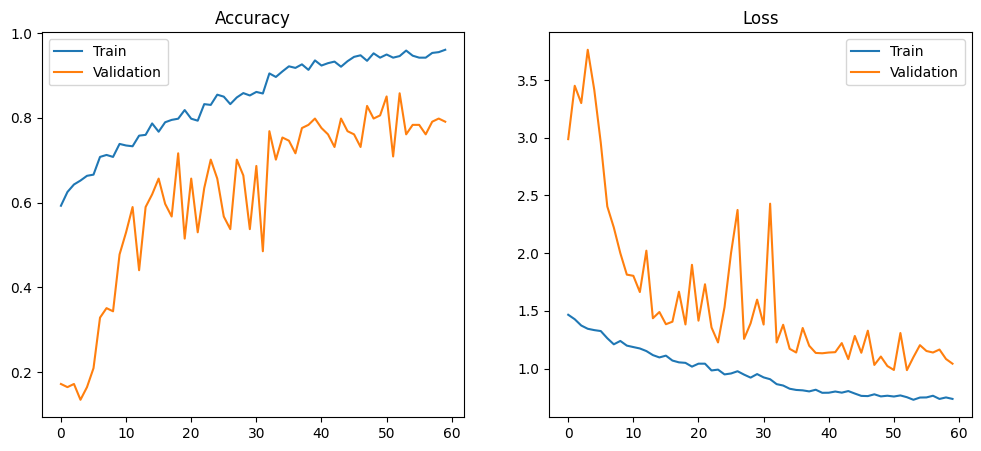

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()

Test

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# 1. Đồng bộ danh sách nhãn chuẩn theo bảng chữ cái từ tập Train
train_class_indices = train_generator.class_indices

# 2. Cấu hình tập test chuẩn (Bắt buộc shuffle=False)
test_generator_fixed = val_test_datagen.flow_from_directory(
    "/content/food_dataset/test",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
    classes=list(train_class_indices.keys())
)

# 3. Tải model xịn nhất vừa lưu từ Checkpoint ra để chấm điểm bài thi
# Lưu ý: Do dùng định dạng .h5 theo file cấu hình cũ của bạn
best_model = tf.keras.models.load_model("/content/drive/MyDrive/best_food_model6.h5")

# 4. Đánh giá độ chính xác tổng quan trên tập Test
loss, acc = best_model.evaluate(test_generator_fixed)
print(f"\n🎯 KẾT QUẢ TEST ACCURACY: {acc*100:.2f}%")
print("-" * 50)

# 5. In báo cáo chi tiết từng món (Classification Report) để check xem món nào bị nhận diện sai
pred = best_model.predict(test_generator_fixed)
y_pred = np.argmax(pred, axis=1)
y_true = test_generator_fixed.classes

print("\n📊 BÁO CÁO CHI TIẾT TỪNG MÓN ĂN:")
print(classification_report(y_true, y_pred, target_names=list(train_class_indices.keys())))

Found 141 images belonging to 12 classes.


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 506ms/step - accuracy: 0.8227 - loss: 1.0534

🎯 KẾT QUẢ TEST ACCURACY: 82.27%
--------------------------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 353ms/step

📊 BÁO CÁO CHI TIẾT TỪNG MÓN ĂN:
                    precision    recall  f1-score   support

   Canh chua có cá       0.89      0.80      0.84        10
Canh chua không cá       0.57      0.73      0.64        11
          Canh rau       1.00      0.60      0.75        15
         Cá hú kho       0.82      0.90      0.86        10
               Cơm       0.93      1.00      0.96        13
           Rau xào       0.73      0.94      0.82        17
        Sườn nướng       0.85      1.00      0.92        11
          Thịt kho       0.71      0.91      0.80        11
    Thịt kho trứng       0.86      0.55      0.67        11
       Trứng chiên       1.00      0.80      0.89        10
  Trứng chiên thịt       0.90      0.82      0.86        11
     Đậu hũ sốt cà       0.90      0.82      0.86 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step


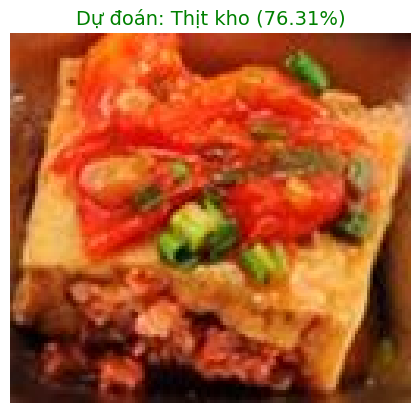


📊 Độ tự tin chi tiết của mô hình:
 - Cá hú kho: 1.27%
 - Rau xào: 2.16%
 - Thịt kho: 76.31%
 - Thịt kho trứng: 5.36%
 - Trứng chiên: 1.20%
 - Đậu hũ sốt cà: 9.54%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. ĐƯỜNG DẪN ẢNH: Thay "ten_anh_cua_ban.jpg" bằng tên file bạn vừa tải lên Colab
IMAGE_PATH = "/content/Anh26.JPG"

# 2. Tải lại sơ đồ nhãn chuẩn theo thứ tự chữ cái từ train_generator
class_names = list(train_generator.class_indices.keys())

# 3. Tải model xịn nhất đã train từ Drive
best_model = tf.keras.models.load_model("/content/drive/MyDrive/best_food_model6.h5")

# 4. Tiền xử lý ảnh giống hệt lúc train (Size 128x128, rescale 1./255)
img = image.load_img(IMAGE_PATH, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Chuẩn hóa ma trận điểm ảnh
img_array = np.expand_dims(img_array, axis=0)  # Tạo batch size = 1

# 5. Dự đoán
predictions = best_model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
confidence = predictions[0][predicted_class_idx] * 100

# 6. Hiển thị kết quả trực quan
plt.imshow(image.load_img(IMAGE_PATH))
plt.axis('off')
plt.title(f"Dự đoán: {class_names[predicted_class_idx]} ({confidence:.2f}%)", fontsize=14, color='green' if confidence > 70 else 'orange')
plt.show()

# In ra bảng tỷ lệ phần trăm đoán của các món khác nếu muốn check độ phân vân
print("\n📊 Độ tự tin chi tiết của mô hình:")
for name, prob in zip(class_names, predictions[0]):
    if prob > 0.01: # Chỉ in những món mô hình nghi ngờ trên 1%
        print(f" - {name}: {prob*100:.2f}%")